# 🎓 Transformaciones Geométricas

En este tema aprenderemos a modificar la geometría de las imágenes. Estas técnicas son fundamentales para la **preparación de datos (Data Augmentation)** en Inteligencia Artificial.

### 🎯 Objetivos de Aprendizaje
1.  **Redimensionar (Resize):** Cambiar el tamaño de las imágenes.
2.  **Recortar (Crop):** Extraer regiones de interés (ROI).
3.  **Rotar:** Girar imágenes manteniendo el centro.
4.  Entender la interpolación.

---

## 1. Redimensionamiento (Resize)

Cambiar el tamaño es necesario porque las redes neuronales suelen requerir entradas de tamaño fijo (ej. 224x224 píxeles).

Tamaño Original: (400, 600)


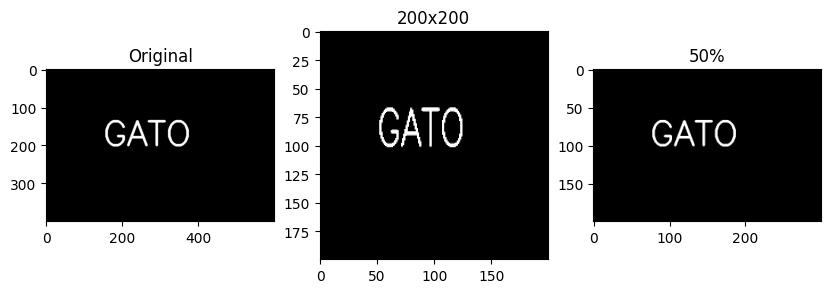

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Cargar imagen de prueba
imagen = cv2.imread('gato.jpg')
if imagen is None:
    imagen = np.zeros((400, 600, 3), dtype=np.uint8) # Imagen negra 400x600 si no hay archivo
    cv2.putText(imagen, "GATO", (150, 200), cv2.FONT_HERSHEY_SIMPLEX, 3, (255, 255, 255), 5)

print(f"Tamaño Original: {imagen.shape[:2]}")

# 1. Redimensionar especificando tamaño exacto (Ancho, Alto)
# OJO: OpenCV usa (Ancho, Alto), mientras que shape retorna (Alto, Ancho)
nuevo_tamano = (200, 200)
img_resized = cv2.resize(imagen, nuevo_tamano)

# 2. Redimensionar por escala (ej. 50%)
img_escala = cv2.resize(imagen, None, fx=0.5, fy=0.5, interpolation=cv2.INTER_AREA)

plt.figure(figsize=(10,5))
plt.subplot(1,3,1); plt.imshow(imagen); plt.title("Original")
plt.subplot(1,3,2); plt.imshow(img_resized); plt.title("200x200")
plt.subplot(1,3,3); plt.imshow(img_escala); plt.title("50%")
plt.show()

## 2. Recorte (Cropping)

En OpenCV (y NumPy), recortar es simplemente hacer **Slicing** de matrices.

Sintaxis: `imagen[y_inicio:y_fin, x_inicio:x_fin]`

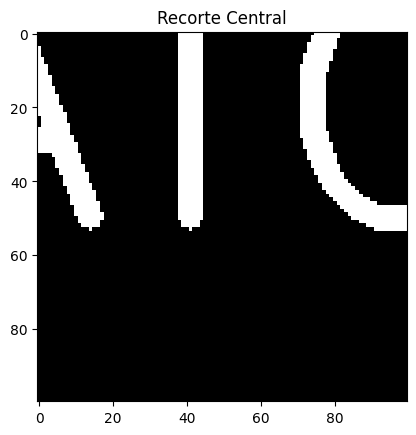

In [ ]:
# Recortar el centro de la imagen
alto, ancho = imagen.shape[:2]

# Coordenadas (Supongamos que queremos un cuadro de 100x100 al centro)
centro_y, centro_x = alto // 2, ancho // 2
y1, y2 = centro_y - 50, centro_y + 50
x1, x2 = centro_x - 50, centro_x + 50

# Aplicar recorte
recorte = imagen[y1:y2, x1:x2]

plt.imshow(recorte)
plt.title("Recorte Central")
plt.show()

## 3. Rotación

Rotar no es tan directo como recortar. Necesitamos:
1.  Calcular el centro de rotación.
2.  Crear una **Matriz de Rotación** (`cv2.getRotationMatrix2D`).
3.  Aplicar la transformación afín (`cv2.warpAffine`).

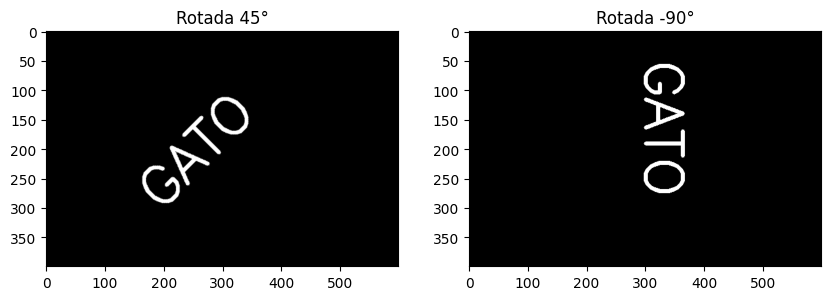

In [ ]:
def rotar_imagen(img, grados):
    alto, ancho = img.shape[:2]
    centro = (ancho // 2, alto // 2)
    
    # Crear matriz de rotación
    # Argumentos: (punto_rotacion, angulo, escala)
    M = cv2.getRotationMatrix2D(centro, grados, 1.0)
    
    # Aplicar matriz
    rotada = cv2.warpAffine(img, M, (ancho, alto))
    return rotada

img_rotada_45 = rotar_imagen(imagen, 45)
img_rotada_90 = rotar_imagen(imagen, -90)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1); plt.imshow(img_rotada_45); plt.title("Rotada 45°")
plt.subplot(1,2,2); plt.imshow(img_rotada_90); plt.title("Rotada -90°")
plt.show()

## 4. 🚀 Mini-Proyecto: Data Augmentation Generator

**Contexto:** Cuando entrenamos IAs, a veces tenemos pocas fotos. Una técnica llamada "Data Augmentation" consiste en generar copias modificadas de nuestras fotos (rotadas, cortadas, espejo) para tener más datos.

**Ejercicio:**
Crea una función `generar_variaciones(imagen)` que reciba una imagen y devuelva una lista con 3 variantes:
1.  Imagen con flip horizontal (`cv2.flip`).
2.  Imagen rotada 30 grados.
3.  Imagen con zoom (Recorte central del 80% redimensionado al tamaño original).

In [ ]:
# TODO: Implementa el mini-proyecto aquí

import cv2
import numpy as np

# --- 1. Generación de Imagen de Prueba (Frutas Sintéticas) ---
imagen = np.zeros((400, 400, 3), dtype=np.uint8)
imagen[:] = 255 # Fondo blanco
# Dibujar "Manzana" (Círculo Rojo)
cv2.circle(imagen, (100, 200), 60, (0, 0, 255), -1) 
# Dibujar "Plátano" (Elipse Amarilla)
cv2.ellipse(imagen, (300, 200), (80, 30), 45, 0, 360, (0, 255, 255), -1)

# --- 2. Función de Data Augmentation ---

def generar_variaciones(img):
    variaciones = []
    alto, ancho = img.shape[:2]
    
    # Variación 1: Flip Horizontal (Espejo)
    # 1 indica volteo horizontal, 0 vertical, -1 ambos
    flip = cv2.flip(img, 1)
    variaciones.append(("Flip Horizontal", flip))
    
    # Variación 2: Rotación 30 grados
    centro = (ancho // 2, alto // 2)
    # Matriz de rotación: (centro, ángulo, escala)
    M = cv2.getRotationMatrix2D(centro, 30, 1.0)
    rotada = cv2.warpAffine(img, M, (ancho, alto), borderValue=(255, 255, 255))
    variaciones.append(("Rotacion 30", rotada))
    
    # Variación 3: Zoom (Recorte central del 80% + Resize al original)
    nuevo_h, nuevo_w = int(alto * 0.8), int(ancho * 0.8)
    
    # Calcular coordenadas para centrar el recorte
    inicio_y = (alto - nuevo_h) // 2
    inicio_x = (ancho - nuevo_w) // 2
    
    # Recortar (Slicing)
    crop = img[inicio_y:inicio_y+nuevo_h, inicio_x:inicio_x+nuevo_w]
    
    # Redimensionar al tamaño original (Zoom)
    zoom = cv2.resize(crop, (ancho, alto), interpolation=cv2.INTER_LINEAR)
    variaciones.append(("Zoom 80%", zoom))
    
    return variaciones

# --- 3. Ejecución y Visualización ---

print("🔄 Generando variaciones de Data Augmentation...")
variantes = generar_variaciones(imagen)

# Mostrar la original
cv2.imshow("Original", imagen)

# Mostrar las variantes generadas
for i, (nombre, img_var) in enumerate(variantes):
    print(f"   > Generada variante: {nombre}")
    cv2.imshow(f"Variacion: {nombre}", img_var)

print("\nPresiona cualquier tecla para cerrar las ventanas...")
cv2.waitKey(0)
cv2.destroyAllWindows()